# Module 11 Challenge
## Deliverable 2: Scrape and Analyze Mars Weather Data

In [5]:
# Import relevant libraries
from splinter import Browser
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import pandas as pd

In [7]:
browser = Browser('chrome')

### Step 1: Visit the Website

Use automated browsing to visit the [Mars Temperature Data Site](https://static.bc-edx.com/data/web/mars_facts/temperature.html). Inspect the page to identify which elements to scrape.

   > **Hint** To identify which elements to scrape, you might want to inspect the page by using Chrome DevTools to discover whether the table contains usable classes.


In [9]:
# Visit the website
# https://static.bc-edx.com/data/web/mars_facts/temperature.html
url = "https://static.bc-edx.com/data/web/mars_facts/temperature.html"
browser.visit(url)

### Step 2: Scrape the Table

Create a Beautiful Soup object and use it to scrape the data in the HTML table.

Note that this can also be achieved by using the Pandas `read_html` function. However, use Beautiful Soup here to continue sharpening your web scraping skills.

In [11]:
# Create a Beautiful Soup Object
html = browser.html
soup = BeautifulSoup(html, 'html.parser')

In [13]:
# Extract all rows of data
table = soup.find('table', class_='table')
rows = table.find_all('tr')

### Step 3: Store the Data

Assemble the scraped data into a Pandas DataFrame. The columns should have the same headings as the table on the website. Here’s an explanation of the column headings:

* `id`: the identification number of a single transmission from the Curiosity rover
* `terrestrial_date`: the date on Earth
* `sol`: the number of elapsed sols (Martian days) since Curiosity landed on Mars
* `ls`: the solar longitude
* `month`: the Martian month
* `min_temp`: the minimum temperature, in Celsius, of a single Martian day (sol)
* `pressure`: The atmospheric pressure at Curiosity's location

In [15]:
columns = [th.text.strip() for th in rows[0].find_all('th')]
# Create an empty list
data = []

# Loop through the scraped data to create a list of rows
for row in rows[1:]:
    row_data = [td.text.strip() for td in row.find_all('td')]
    data.append(row_data)

In [19]:
# Create a Pandas DataFrame by using the list of rows and a list of the column names
mars_weather_df = pd.DataFrame(data, columns=columns)

In [21]:
# Confirm DataFrame was created successfully
print(mars_weather_df.head())

   id terrestrial_date sol   ls month min_temp pressure
0   2       2012-08-16  10  155     6    -75.0    739.0
1  13       2012-08-17  11  156     6    -76.0    740.0
2  24       2012-08-18  12  156     6    -76.0    741.0
3  35       2012-08-19  13  157     6    -74.0    732.0
4  46       2012-08-20  14  157     6    -74.0    740.0


### Step 4: Prepare Data for Analysis

Examine the data types that are currently associated with each column. If necessary, cast (or convert) the data to the appropriate `datetime`, `int`, or `float` data types.

  > **Hint** You can use the Pandas `astype` and `to_datetime` methods to accomplish this task.


In [23]:
# Examine data type of each column
print(mars_weather_df.dtypes)

id                  object
terrestrial_date    object
sol                 object
ls                  object
month               object
min_temp            object
pressure            object
dtype: object


In [25]:
# Change data types for data analysis
mars_weather_df['id'] = mars_weather_df['id'].astype(int)
mars_weather_df['terrestrial_date'] = pd.to_datetime(mars_weather_df['terrestrial_date'])
mars_weather_df['sol'] = mars_weather_df['sol'].astype(int)
mars_weather_df['ls'] = mars_weather_df['ls'].astype(int)
mars_weather_df['month'] = mars_weather_df['month'].astype(int)
mars_weather_df['min_temp'] = mars_weather_df['min_temp'].astype(float)
mars_weather_df['pressure'] = mars_weather_df['pressure'].astype(float)

In [27]:
# Confirm type changes were successful by examining data types again
print(mars_weather_df.dtypes)

id                           int32
terrestrial_date    datetime64[ns]
sol                          int32
ls                           int32
month                        int32
min_temp                   float64
pressure                   float64
dtype: object


### Step 5: Analyze the Data

Analyze your dataset by using Pandas functions to answer the following questions:

1. How many months exist on Mars?
2. How many Martian (and not Earth) days worth of data exist in the scraped dataset?
3. What are the coldest and the warmest months on Mars (at the location of Curiosity)? To answer this question:
    * Find the average the minimum daily temperature for all of the months.
    * Plot the results as a bar chart.
4. Which months have the lowest and the highest atmospheric pressure on Mars? To answer this question:
    * Find the average the daily atmospheric pressure of all the months.
    * Plot the results as a bar chart.
5. About how many terrestrial (Earth) days exist in a Martian year? To answer this question:
    * Consider how many days elapse on Earth in the time that Mars circles the Sun once.
    * Visually estimate the result by plotting the daily minimum temperature.


In [31]:
# 1. How many months are there on Mars?
num_months = mars_weather_df['month'].nunique()
print(f"Number of months on Mars: {num_months}")

Number of months on Mars: 12


In [33]:
# 2. How many sols (Martian days) worth of data are there?
num_sols = mars_weather_df['sol'].nunique()

print(f"Number of Martian days (sols) recorded: {num_sols}")

Number of Martian days (sols) recorded: 1867


In [35]:
# 3. What is the average minimum temperature by month?
avg_mars_temp_by_month = mars_weather_df.groupby('month')['min_temp'].mean()
print(avg_mars_temp_by_month)

month
1    -77.160920
2    -79.932584
3    -83.307292
4    -82.747423
5    -79.308725
6    -75.299320
7    -72.281690
8    -68.382979
9    -69.171642
10   -71.982143
11   -71.985507
12   -74.451807
Name: min_temp, dtype: float64


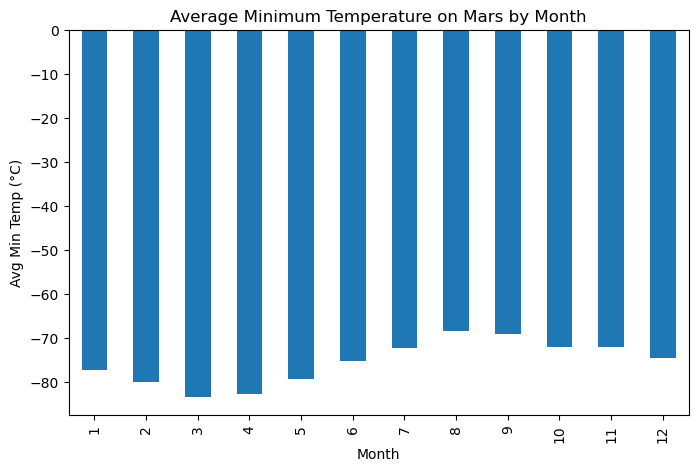

In [39]:
# Plot the average minimum temperature by month
plt.figure(figsize=(8,5))
avg_mars_temp_by_month.plot(kind='bar')
plt.xlabel('Month')
plt.ylabel('Avg Min Temp (°C)')
plt.title('Average Minimum Temperature on Mars by Month')
plt.show()

In [41]:
# Identify the coldest and hottest months in Curiosity's location by sorting the previous graph
sorted_monthly_temps = avg_mars_temp_by_month.sort_values()

print(sorted_monthly_temps)

month
3    -83.307292
4    -82.747423
2    -79.932584
5    -79.308725
1    -77.160920
6    -75.299320
12   -74.451807
7    -72.281690
11   -71.985507
10   -71.982143
9    -69.171642
8    -68.382979
Name: min_temp, dtype: float64


In [43]:
# 4. What is the average pressure by month?
avg_monthly_pressure = mars_weather_df.groupby('month')['pressure'].mean()
print(avg_monthly_pressure)

month
1     862.488506
2     889.455056
3     877.322917
4     806.329897
5     748.557047
6     745.054422
7     795.105634
8     873.829787
9     913.305970
10    887.312500
11    857.014493
12    842.156627
Name: pressure, dtype: float64


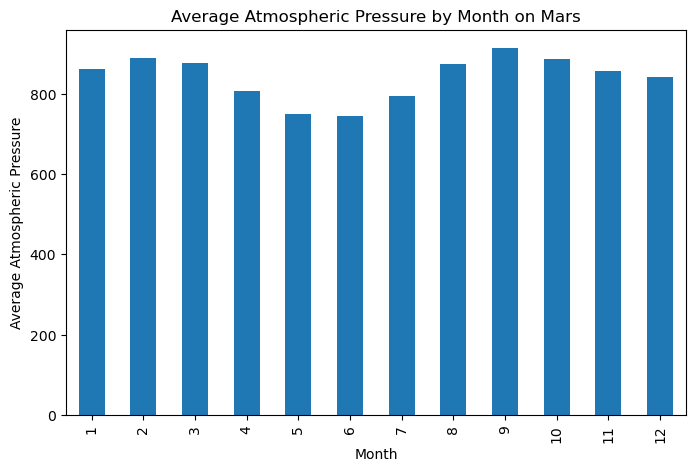

In [45]:
# Plot the average pressure by month
plt.figure(figsize=(8, 5))
avg_monthly_pressure.plot(kind='bar')
plt.xlabel('Month')
plt.ylabel('Average Atmospheric Pressure')
plt.title('Average Atmospheric Pressure by Month on Mars')
plt.show()

In [51]:
# Identify the lowest and highest pressure months in Curiosity's location by sorting the previous graph
sorted_monthly_pressure = avg_monthly_pressure.sort_values()

print(sorted_monthly_pressure)

month
6     745.054422
5     748.557047
7     795.105634
4     806.329897
12    842.156627
11    857.014493
1     862.488506
8     873.829787
3     877.322917
10    887.312500
2     889.455056
9     913.305970
Name: pressure, dtype: float64


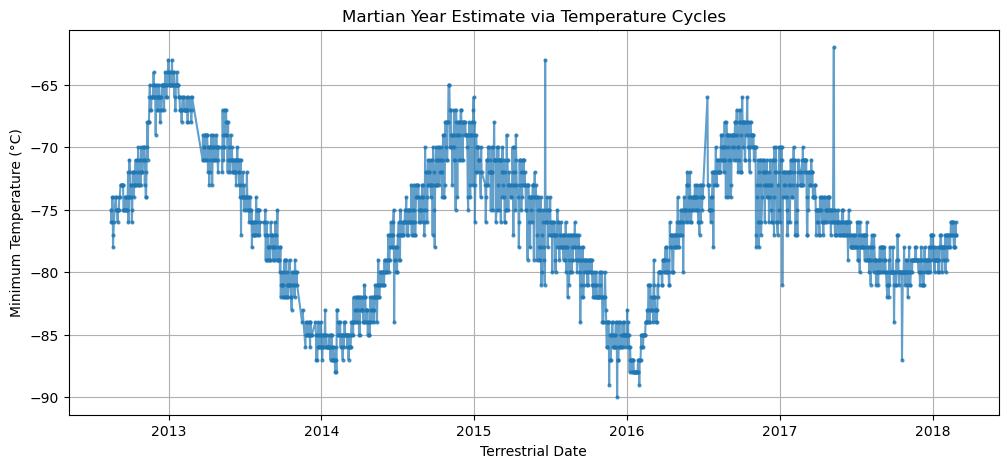

In [57]:
# 5. How many terrestrial (Earth) days are there in a Martian year?
# Visually estimate the result by plotting the daily minimum temperature of each observation in the data set.
# Ensure figsize is a tuple (width, height)
plt.figure(figsize=(12, 5))

# Plot minimum temperature over time
plt.plot(mars_weather_df['terrestrial_date'], mars_weather_df['min_temp'], marker='o', linestyle='-', markersize=2, alpha=0.7)

# Labels and title
plt.xlabel('Terrestrial Date')
plt.ylabel('Minimum Temperature (°C)')
plt.title('Martian Year Estimate via Temperature Cycles')
plt.grid(True)

# Show the plot
plt.show()

#### Minimum Temperature

- The hottest month on Mars appears to be the 8th month.
- The coldest month on Mars is month 3.
- the temperatures appear to follow seasonal cycles, with colder months showcasing lower cyclic average temperatures
- colder months correspond to when Mars is further away from the sun, while hotter months are evident that the planet is closer to the sun
- the seasons are not equal in length. this suggests that there is an elliptical orbit and not a circular or parabolic

#### Atmospheric Pressure

- The month with the lowest pressure is Month 6
- The month with the highest pressure is Month 9
- Pressure fluctuates with high variance

#### Year Length
- According to the temperature plot, a Martian year is a touch below 2 earth years, ~687 earth days equals an entire year on mars
- The seasonal changes allow us to estimate yearly length based on temperature cycles

### Step 6: Save the Data

Export the DataFrame to a CSV file.

In [61]:
# Write the data to a CSV
mars_weather_df.to_csv("mars_weather.csv", index=False)

print("Successfully saved to mars_weather.csv")

Successfully saved to mars_weather.csv


In [63]:
browser.quit()